In [1]:
import os
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
files = glob.glob('./dataview/*.xlsx')
files = [file for file in files if 'CoT' not in file]

scenario = list()
subtask = list()
accuracy = list()
for file in files:
    df = pd.read_excel(file, sheet_name='SubTask')
    if 'JSON' in file:
        path_finding_accuracy = df[df['SubTask'].isin(['path_up_to_down', 'path_down_to_up', 'path_between_nodes'])]['mean'].mean()
        nearest_ancestor_accuracy = df[df['SubTask'].isin(['shared_ancestor_diff_level', 'shared_ancestor_same_level'])]['mean'].mean()
        df = pd.concat([
            df,
            pd.DataFrame(dict(SubTask=['path_finding'], mean=[path_finding_accuracy])),
            pd.DataFrame(dict(SubTask=['nearest_ancestor'], mean=[nearest_ancestor_accuracy])),
            ], ignore_index=True)
        df = df[~df['SubTask'].isin(['path_up_to_down', 'path_down_to_up', 'path_between_nodes', 'shared_ancestor_diff_level', 'shared_ancestor_same_level'])]
    scenario.extend([os.path.basename(file).rstrip('.xlsx')] * df.shape[0])
    subtask.extend(df['SubTask'].values.tolist())
    accuracy.extend(df['mean'].values.tolist())

task_hardness = pd.DataFrame(dict(scenario=scenario, subtask=subtask, accuracy=accuracy))
task_hardness = task_hardness.sort_values('accuracy', ascending=False)
task_hardness

,scenario,subtask,accuracy
12,multiple-tree,leaf,94.610667
15,multiple-tree,root,93.133500
29,formula,equivalent,88.889195
21,binary-tree,balance,87.296017
11,multiple-tree,isomorphic,86.434000
3,JSON,node_attribute,73.157842
0,JSON,child_count,70.247632
16,code,SpaceComplexity,56.475000
17,code,TimeComplexity,54.575000
10,multiple-tree,common_ancestor,54.122167


In [3]:
subtask_map = {
    'leaf': 'Leaf',
    'root': 'Root',
    'equivalent': 'Equivalent',
    'balance': 'Balance',
    'isomorphic': 'Isomorphic',
    'node_attribute': 'Node Attribute',
    'child_count': 'Child Count',
    'SpaceComplexity': 'Space Complexity',
    'TimeComplexity': 'Time Complexity',
    'common_ancestor': 'Common Ancestor',
    'outline_extraction': 'Outline Extraction',
    'convert': 'Convert',
    'level_nodes': 'Level Nodes',
    'nearest_ancestor': 'Nearest Ancestor',
    'all_children': 'All Children',
    'traversal_order_verification': 'Traversal Verf.',
    'level_count': 'Level Count',
    'node_depth': 'Node Depth',
    'all_ancestor': 'All Ancestor',
    'remove_node': 'Remove Node',
    'add_node': 'Add Node',
    'prefix_traversal': 'Prefix Traversal',
    'disordered_section': 'Disordered Section',
    'contextual_qa': 'Contextual QA',
    'path_finding': 'Path Finding',
    'postfix_traversal': 'Postfix Traversal',
    'mirror_tree': 'Mirror Tree',
    'infix_traversal': 'Infix Traversal',
    'calculate': 'Calculate'
}
task_hardness['subtask'] = task_hardness['subtask'].map(subtask_map)


scenario_map = {
    'multiple-tree': 'Multiple Tree',
    'formula': 'Formula',
    'binary-tree': 'Binary Tree',
    'JSON': 'JSON',
    'code': 'Code',
    'paper': 'Paper'
}
task_hardness['scenario'] = task_hardness['scenario'].map(scenario_map)

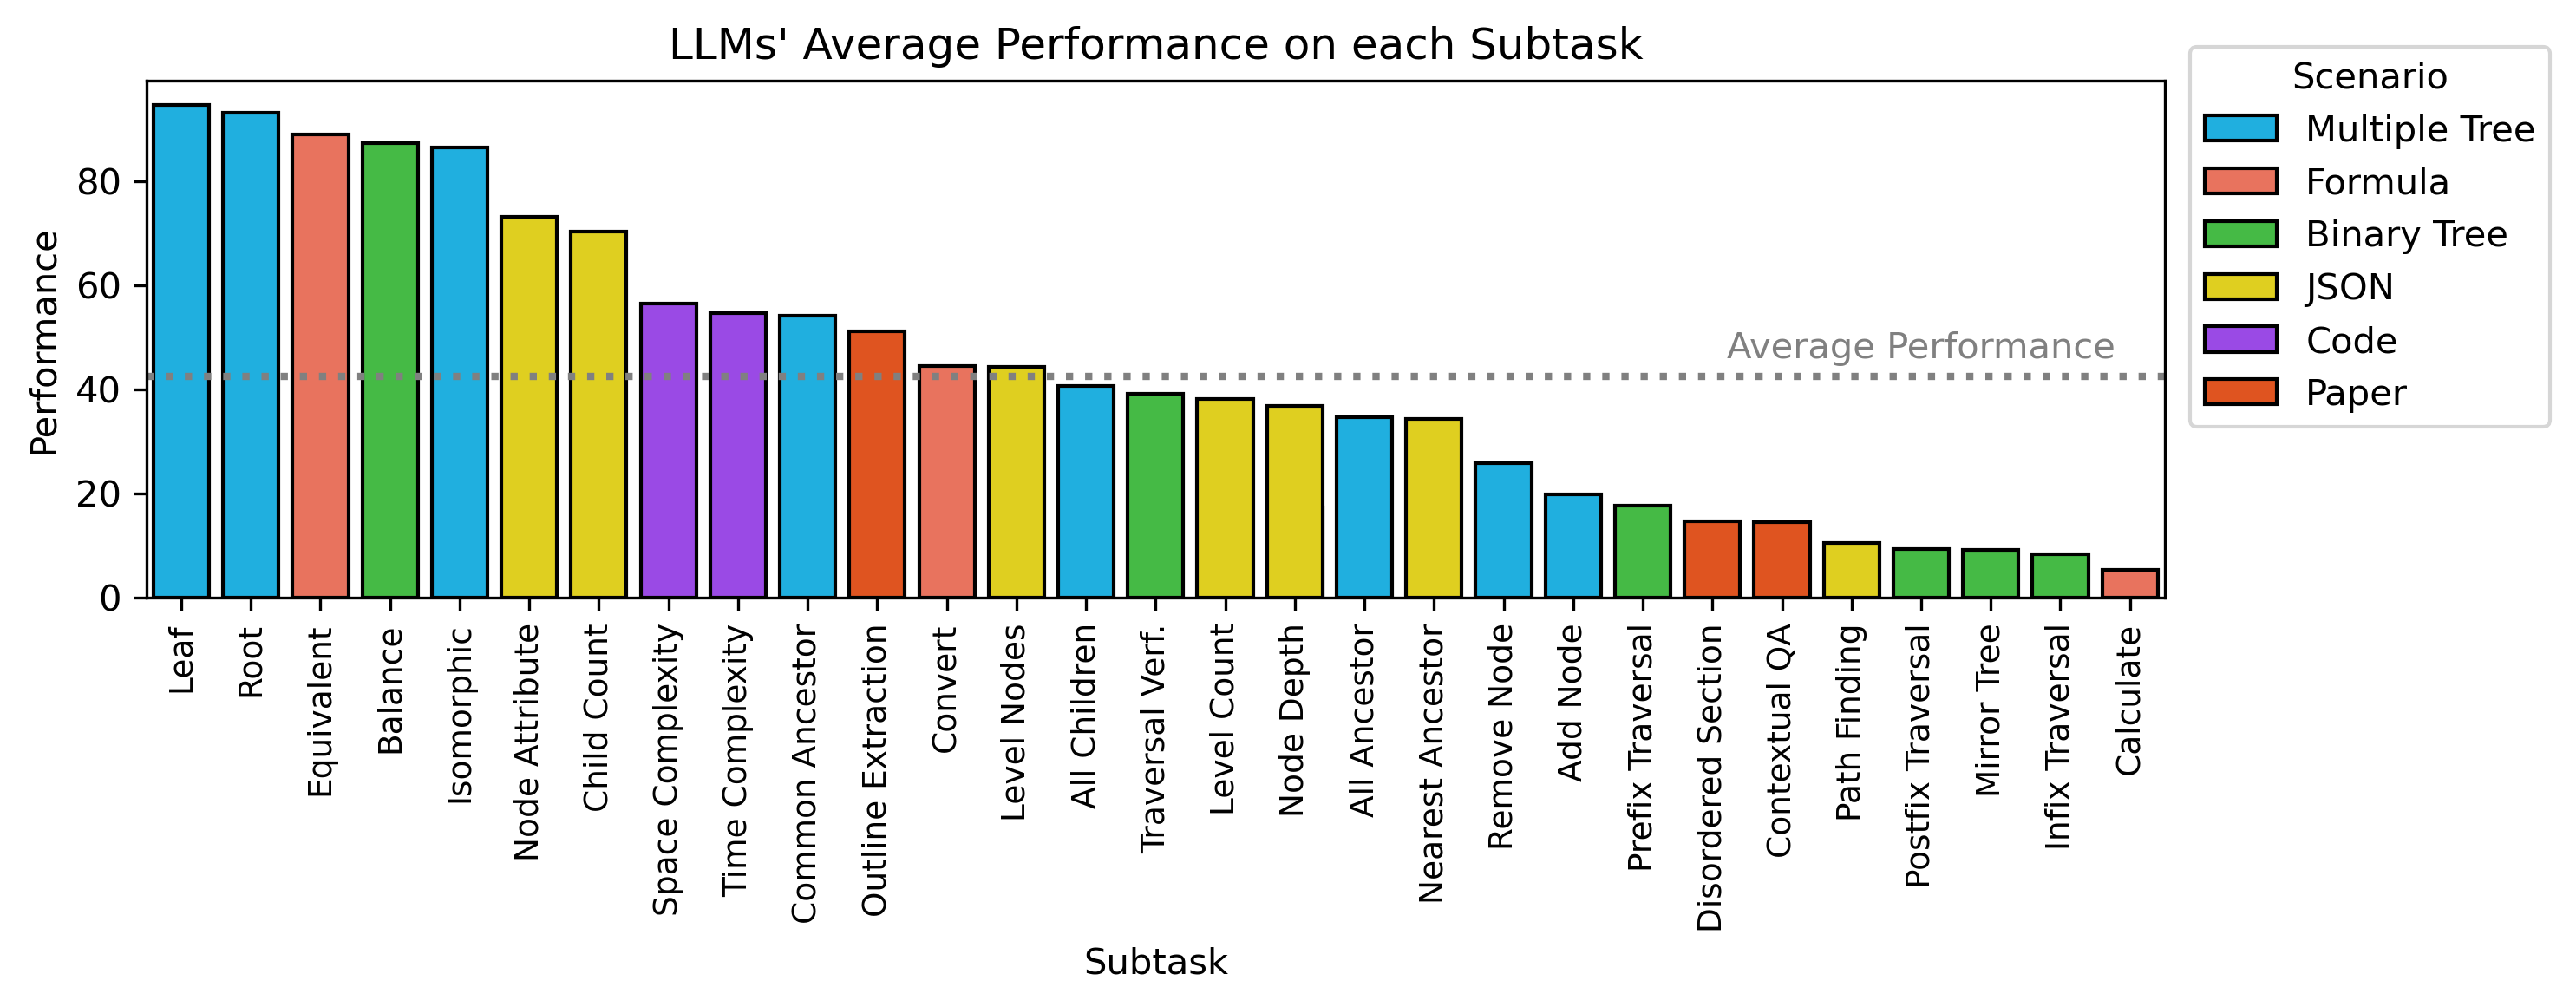

In [4]:
color_palette = {
    'Multiple Tree': '#00BFFF',
    'Formula': '#FF6347',
    'Binary Tree': '#32CD32',
    'JSON': '#FFEA00',
    'Code': '#9B30FF',
    'Paper': '#FF4500'
}
plt.figure(figsize=(10, 4), dpi=300)

ax = sns.barplot(x='subtask', y='accuracy', data=task_hardness, hue='scenario', palette=color_palette, dodge=False)
for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1)

average_performance = task_hardness['accuracy'].mean()
plt.axhline(y=average_performance, color='grey', linestyle=':', linewidth=2)
plt.text(x=25, y=average_performance + 2, s='Average Performance', color='grey', fontsize=10, ha='center', va='bottom')

plt.xticks(rotation=90, fontsize=9)
plt.xlabel('Subtask')
plt.ylabel('Performance')
plt.title('LLMs\' Average Performance on each Subtask')
plt.legend(title='Scenario', loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()